# Stock Prediction LSTM - Tokesi Lukynawa

## Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler,RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout, Input)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Untuk reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow version: {tf.__version__}')
print('✅ Semua library berhasil diimport!')

TensorFlow version: 2.21.0
✅ Semua library berhasil diimport!


## Eksplorasi Data (EDA) & Praproses

### Load Dataset

In [25]:
df_googl = pd.read_csv('GOOGL.csv', parse_dates=['Date'])
df_intc  = pd.read_csv('INTC.csv',  parse_dates=['Date'])

print('=== GOOGL (Alphabet Inc.) ===')
print(f'Jumlah baris: {len(df_googl)}')
print(f'Periode: {df_googl["Date"].min().date()} s/d {df_googl["Date"].max().date()}\n')
print(df_googl.head(3))

print('\n=== INTC (Intel Corporation) ===')
print(f'Jumlah baris: {len(df_intc)}')
print(f'Periode: {df_intc["Date"].min().date()} s/d {df_intc["Date"].max().date()}\n')
print(df_intc.head(3))

=== GOOGL (Alphabet Inc.) ===
Jumlah baris: 3932
Periode: 2004-08-19 s/d 2020-04-01

        Date       Open       High        Low      Close  Adj Close    Volume
0 2004-08-19  50.050049  52.082081  48.028027  50.220219  50.220219  44659000
1 2004-08-20  50.555557  54.594593  50.300301  54.209209  54.209209  22834300
2 2004-08-23  55.430431  56.796795  54.579578  54.754753  54.754753  18256100

=== INTC (Intel Corporation) ===
Jumlah baris: 10098
Periode: 1980-03-17 s/d 2020-04-01

        Date      Open      High       Low     Close  Adj Close    Volume
0 1980-03-17  0.325521  0.330729  0.325521  0.325521   0.204750  10924800
1 1980-03-18  0.325521  0.328125  0.322917  0.322917   0.203112  17068800
2 1980-03-19  0.330729  0.335938  0.330729  0.330729   0.208026  18508800


### Statistika Deskriptif

In [26]:
print('=== Statistik Deskriptif GOOGL ===\n')
print(df_googl[['Open','High','Low','Close','Volume']].describe().round(2))

print('\n=== Statistik Deskriptif INTC ===\n')
print(df_intc[['Open','High','Low','Close','Volume']].describe().round(2))

=== Statistik Deskriptif GOOGL ===

          Open     High      Low    Close       Volume
count  3932.00  3932.00  3932.00  3932.00      3932.00
mean    509.12   513.77   504.12   509.07   7047423.07
std     356.98   359.97   353.93   357.15   7959721.62
min      49.64    50.92    48.03    50.06    520600.00
25%     239.72   241.66   236.71   238.70   1902550.00
50%     327.63   331.89   324.44   327.72   4337100.00
75%     757.72   763.54   752.02   758.50   8914150.00
max    1527.20  1530.74  1520.98  1524.87  82151100.00

=== Statistik Deskriptif INTC ===

           Open      High       Low     Close        Volume
count  10098.00  10098.00  10098.00  10098.00  1.009800e+04
mean      17.77     18.02     17.53     17.77  5.177404e+07
std       16.11     16.34     15.89     16.11  3.557862e+07
min        0.22      0.22      0.22      0.22  0.000000e+00
25%        1.13      1.15      1.12      1.13  2.762385e+07
50%       19.27     19.51     19.03     19.26  4.623640e+07
75%       27.

### Missing Value

In [27]:
print('=== Missing Values GOOGL ===\n')
print(df_googl.isnull().sum())

print('\n=== Missing Values INTC ===\n')
print(df_intc.isnull().sum())

=== Missing Values GOOGL ===

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

=== Missing Values INTC ===

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


### Visualisasi Harga `Close`

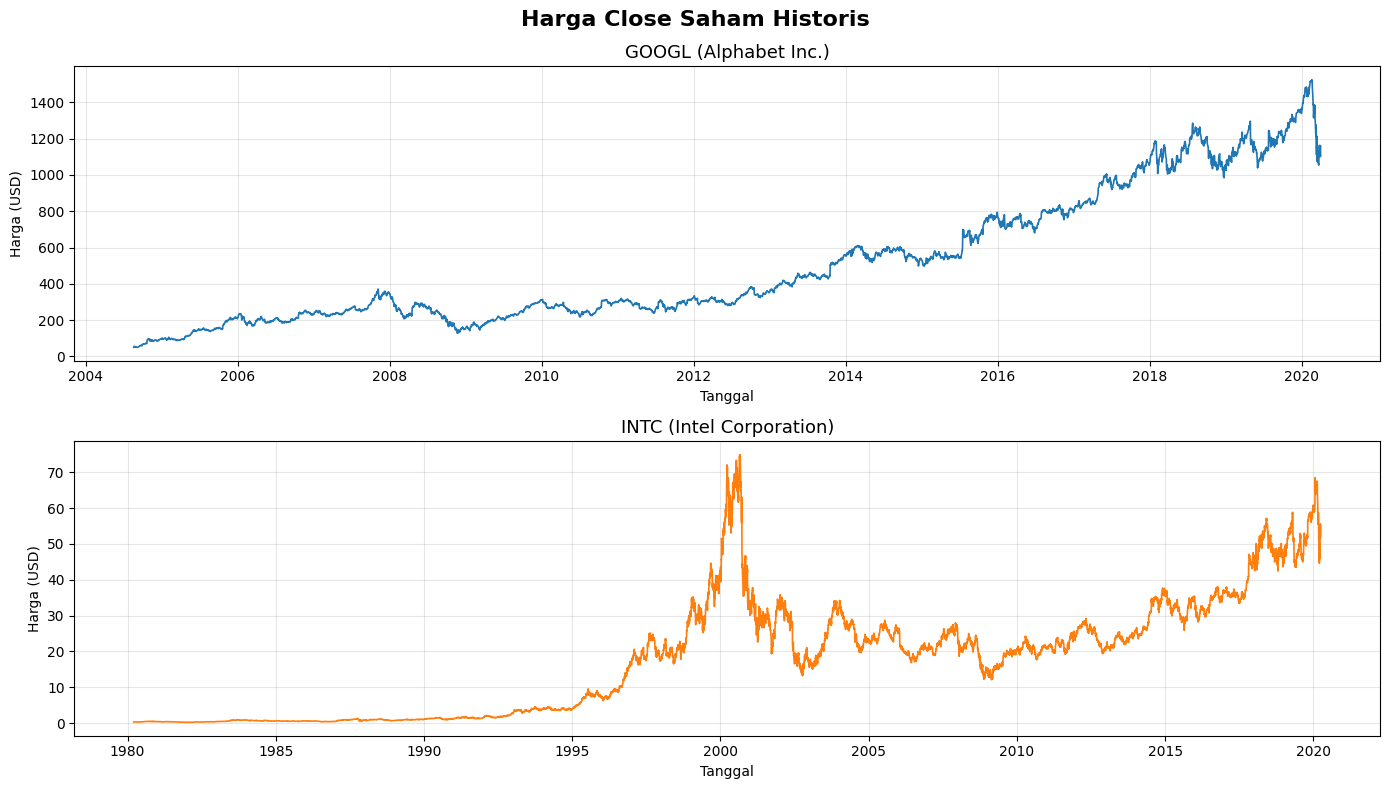

In [28]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Harga Close Saham Historis', fontsize=16, fontweight='bold')

# GOOGL
axes[0].plot(df_googl['Date'], df_googl['Close'], color='#1f77b4', linewidth=1.2)
axes[0].set_title('GOOGL (Alphabet Inc.)', fontsize=13)
axes[0].set_ylabel('Harga (USD)')
axes[0].set_xlabel('Tanggal')
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# INTC
axes[1].plot(df_intc['Date'], df_intc['Close'], color='#ff7f0e', linewidth=1.2)
axes[1].set_title('INTC (Intel Corporation)', fontsize=13)
axes[1].set_ylabel('Harga (USD)')
axes[1].set_xlabel('Tanggal')
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('01_harga_close_historis.png', dpi=150, bbox_inches='tight')
plt.show()

### Preprocessing

- Data dipilih pada kolom `Date` dan `Close`, kemudian diurutkan berdasarkan kolom `Date`.
- Kolom yang duplikat akan di drop dan semua index akan direset

In [29]:
def preprocess_stock(df, ticker_name):
    df_proc = df[['Date', 'Close']].copy()
    df_proc = df_proc.sort_values('Date').drop_duplicates('Date').reset_index(drop=True)
    print(f'[{ticker_name}] Shape setelah praproses: {df_proc.shape}')
    print(f'[{ticker_name}] Periode: {df_proc["Date"].min().date()} → {df_proc["Date"].max().date()}\n')
    return df_proc

df_googl_proc = preprocess_stock(df_googl, 'GOOGL')
df_intc_proc  = preprocess_stock(df_intc,  'INTC')

print('\nContoh data GOOGL setelah praproses:\n')
print(df_googl_proc.head())

print('\nContoh data GOOGL setelah praproses:\n')
print(df_intc_proc.head())

[GOOGL] Shape setelah praproses: (3932, 2)
[GOOGL] Periode: 2004-08-19 → 2020-04-01

[INTC] Shape setelah praproses: (10098, 2)
[INTC] Periode: 1980-03-17 → 2020-04-01


Contoh data GOOGL setelah praproses:

        Date      Close
0 2004-08-19  50.220219
1 2004-08-20  54.209209
2 2004-08-23  54.754753
3 2004-08-24  52.487488
4 2004-08-25  53.053055

Contoh data GOOGL setelah praproses:

        Date     Close
0 1980-03-17  0.325521
1 1980-03-18  0.322917
2 1980-03-19  0.330729
3 1980-03-20  0.329427
4 1980-03-21  0.317708


### Splitting Data Train & Test

Test data set terdiri dari data 1 tahun terakhir, sedangkan train data set terdiri dari data pada periode sebelumnya.

In [30]:
def split_train_test(df, ticker_name):
    max_date = df['Date'].max()
    split_date = max_date - pd.DateOffset(years=1)

    train = df[df['Date'] <= split_date].copy().reset_index(drop=True)
    test  = df[df['Date'] > split_date].copy().reset_index(drop=True)

    total = len(train) + len(test)
    train_pct = len(train) / total * 100
    test_pct  = len(test) / total * 100

    print(f'\n[{ticker_name}]')
    print(f'  Train: {len(train)} baris ({train_pct:.2f}%) | {train["Date"].min().date()} → {train["Date"].max().date()}')
    print(f'  Test : {len(test)} baris ({test_pct:.2f}%) | {test["Date"].min().date()} → {test["Date"].max().date()}')

    return train, test, split_date

train_googl, test_googl, split_date_googl = split_train_test(df_googl_proc, 'GOOGL')
train_intc,  test_intc,  split_date_intc  = split_train_test(df_intc_proc, 'INTC')


[GOOGL]
  Train: 3679 baris (93.57%) | 2004-08-19 → 2019-04-01
  Test : 253 baris (6.43%) | 2019-04-02 → 2020-04-01

[INTC]
  Train: 9845 baris (97.49%) | 1980-03-17 → 2019-04-01
  Test : 253 baris (2.51%) | 2019-04-02 → 2020-04-01


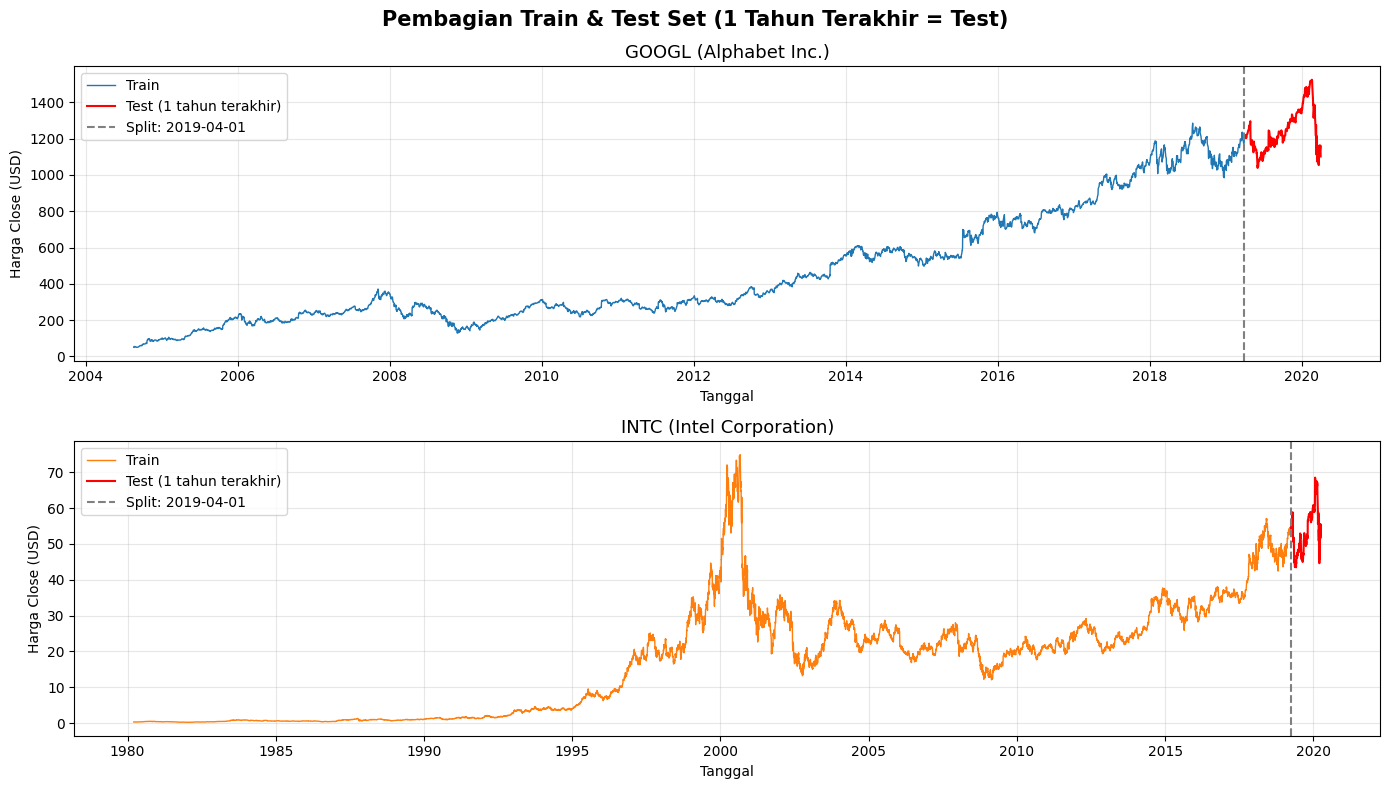

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Pembagian Train & Test Set (1 Tahun Terakhir = Test)', fontsize=15, fontweight='bold')

for ax, train, test, split, title, color in zip(
    axes,
    [train_googl, train_intc],
    [test_googl,  test_intc],
    [split_date_googl, split_date_intc],
    ['GOOGL (Alphabet Inc.)', 'INTC (Intel Corporation)'],
    ['#1f77b4', '#ff7f0e']
):
    ax.plot(train['Date'], train['Close'], color=color,   linewidth=1,   label='Train')
    ax.plot(test['Date'],  test['Close'],  color='red',   linewidth=1.5, label='Test (1 tahun terakhir)')
    ax.axvline(x=split, color='gray', linestyle='--', linewidth=1.5, label=f'Split: {split.date()}')
    ax.set_title(title, fontsize=13)
    ax.set_ylabel('Harga Close (USD)')
    ax.set_xlabel('Tanggal')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('02_train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

### Normalisasi Data

In [ ]:
def robust_scale_data(train, test, column='Close'):
    scaler = RobustScaler()
    
    train_scaled = scaler.fit_transform(train[[column]])
    test_scaled  = scaler.transform(test[[column]])
    
    return train_scaled, test_scaled, scaler

train_googl_scaled, test_googl_scaled, scaler_googl = robust_scale_data(train_googl, test_googl)
train_intc_scaled,  test_intc_scaled,  scaler_intc  = robust_scale_data(train_intc,  test_intc)

print('Range data GOOGL setelah normalisasi:\n')
print(f'  Train: min = {train_googl_scaled.min():.4f}, max = {train_googl_scaled.max():.4f}')
print(f'  Test : min = {test_googl_scaled.min():.4f},  max = {test_googl_scaled.max():.4f}')

print('\nRange data INTC setelah normalisasi:\n')
print(f'  Train: min = {train_intc_scaled.min():.4f}, max = {train_intc_scaled.max():.4f}')
print(f'  Test : min = {test_intc_scaled.min():.4f},  max = {test_intc_scaled.max():.4f}')

Range data GOOGL setelah normalisasi:

  Train: min = -0.6314, max = 2.3857
  Test : min = 1.7831,  max = 2.9703

Range data INTC setelah normalisasi:

  Train: min = -0.7364, max = 2.2052
  Test : min = 0.9674,  max = 1.9529


Data dinormalisasi menggunakan **RobustScaler** berdasarkan **median** dan **Interquartile Range (IQR)** agar lebih tahan terhadap *outlier*, dengan scaler di-*fit* hanya pada data train untuk menghindari *data leakage* sebelum digunakan untuk mentransformasi data train dan data test.

### Windowing

Data dibentuk menjadi pasangan **X** dan **y** menggunakan *sliding window*, di mana **5 hari sebelumnya** digunakan sebagai input untuk memprediksi **1 hari berikutnya**.

Yang artinya :
- window_size : 5
- horizon     : 1
    

In [33]:
def create_sequences(data, window_size=5, horizon=1):
    X, y = [], []
    for i in range(len(data) - window_size - horizon + 1):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size + horizon - 1])
    return np.array(X), np.array(y)

WINDOW_SIZE = 5
HORIZON     = 1

X_googl, y_googl = create_sequences(train_googl_scaled, WINDOW_SIZE, HORIZON)
X_intc,  y_intc  = create_sequences(train_intc_scaled,  WINDOW_SIZE, HORIZON)

print(f'GOOGL → X shape: {X_googl.shape}, y shape: {y_googl.shape}')
print(f'INTC  → X shape: {X_intc.shape},  y shape: {y_intc.shape}')
print(f'\nContoh X[0] GOOGL (5 hari input):\n{X_googl[0].flatten()}')
print(f'Contoh y[0] GOOGL (target hari ke-6): {float(y_googl[0]):.6f}')

GOOGL → X shape: (3674, 5, 1), y shape: (3674, 1)
INTC  → X shape: (9840, 5, 1),  y shape: (9840, 1)

Contoh X[0] GOOGL (5 hari input):
[-0.63096314 -0.6212216  -0.61988933 -0.62542623 -0.62404506]
Contoh y[0] GOOGL (target hari ke-6): -0.621711


### Split Training 

Proses ini akan membagi data training menjadi :
- Training set sebesar 90% untuk training model
- Validation set sebesar 10% untuk monitor model performance untuk mencegah overfitting

In [34]:
def train_val_split(X, y, val_ratio=0.1):
    n_val = int(len(X) * val_ratio)
    n_train = len(X) - n_val
    
    X_train, X_val = X[:n_train], X[n_train:]
    y_train, y_val = y[:n_train], y[n_train:]
    return X_train, X_val, y_train, y_val

# GOOGL
X_train_g, X_val_g, y_train_g, y_val_g = train_val_split(X_googl, y_googl)

# INTC
X_train_i, X_val_i, y_train_i, y_val_i = train_val_split(X_intc,  y_intc)

print('=== GOOGL ===\n')
print(f'  X_train: {X_train_g.shape} | X_val: {X_val_g.shape}')
print(f'  y_train: {y_train_g.shape} | y_val: {y_val_g.shape}')

print('\n=== INTC ===\n')
print(f'  X_train: {X_train_i.shape} | X_val: {X_val_i.shape}')
print(f'  y_train: {y_train_i.shape} | y_val: {y_val_i.shape}')


=== GOOGL ===

  X_train: (3307, 5, 1) | X_val: (367, 5, 1)
  y_train: (3307, 1) | y_val: (367, 1)

=== INTC ===

  X_train: (8856, 5, 1) | X_val: (984, 5, 1)
  y_train: (8856, 1) | y_val: (984, 1)


In [ ]:
def create_test_sequences(train_scaled, test_scaled, window_size=5, horizon=1):
    full_data = np.concatenate([train_scaled, test_scaled], axis=0)
    start_idx = len(train_scaled)
    X_test, y_test = [], []
    for i in range(start_idx, len(full_data) - horizon + 1):
        X_test.append(full_data[i - window_size : i])
        y_test.append(full_data[i + horizon - 1])
    return np.array(X_test), np.array(y_test)

X_test_g, y_test_g = create_test_sequences(train_googl_scaled, test_googl_scaled)
X_test_i, y_test_i = create_test_sequences(train_intc_scaled,  test_intc_scaled)

print(f'\nTest GOOGL → X: {X_test_g.shape}, y: {y_test_g.shape}')
print(f'Test INTC  → X: {X_test_i.shape}, y: {y_test_i.shape}')


Test GOOGL → X: (253, 5, 1), y: (253, 1)
Test INTC  → X: (253, 5, 1), y: (253, 1)


Data test diubah menjadi pasangan **X_test** dan **y_test** menggunakan *sliding window* yang sama seperti data train. Untuk membentuk window pertama pada periode test, digunakan **5 data terakhir dari train** sebagai konteks historis sehingga proses evaluasi model dapat dilakukan dengan benar.

## Arsitektur Baseline LSTM

### Baseline Architecture

Arsitektur baseline :
- **LSTM Layer**: units = 50, activation = ReLU
- **Dense Layer (Perceptron)**: units = 1 (output prediksi)
- **Loss**: MSE (Mean Squared Error)
- **Optimizer**: Adam

In [ ]:
def build_baseline_lstm(window_size=5):
    model = Sequential([
        
        # Input layer
        Input(shape=(window_size, 1)),
        
        # LSTM Layer
        LSTM(units=50, activation='relu'),
        
        # Output layer
        Dense(units=1)
    ], name='Baseline_LSTM')
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

# Tampilan arsitektur
baseline_model = build_baseline_lstm(WINDOW_SIZE)
baseline_model.summary()

Model: "Baseline_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

### Training Baseline Model (GOOGL)

In [ ]:
early_stop_googl = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

print('Training Baseline LSTM (GOOGL)')
print('='*50)

baseline_googl = build_baseline_lstm(WINDOW_SIZE)

history_baseline_googl = baseline_googl.fit(
    X_train_g, y_train_g,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_g, y_val_g),
    callbacks=[early_stop_googl],
    verbose=1
)

Training Baseline LSTM (GOOGL)
Epoch 1/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0960 - mae: 0.1751 - val_loss: 0.1253 - val_mae: 0.3178
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0011 - mae: 0.0228 - val_loss: 0.1200 - val_mae: 0.3132
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.0621e-04 - mae: 0.0187 - val_loss: 0.0906 - val_mae: 0.2697
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.1415e-04 - mae: 0.0178 - val_loss: 0.0702 - val_mae: 0.2351
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5825e-04 - mae: 0.0173 - val_loss: 0.0566 - val_mae: 0.2090
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2392e-04 - mae: 0.0169 - val_loss: 0.0474 - val_mae: 0.1895
Epoch 7/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.0096e-04 - mae: 0.0167 - val_loss: 0.0398 - val_mae: 0.1717
Epoch 8/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.8403e-04 - mae: 0.0165 - val_loss: 0.0336 - val_mae: 0.1561
E

Model menghasilkan 
- **loss = 0.000038**
- **MAE = 0.0043**
- **val_loss = 0.000305**
- **val_mae = 0.0131**. 

Nilai error yang rendah menunjukkan bahwa model mampu mempelajari pola data dengan baik. Perbedaan antara metrik training dan validasi masih tergolong wajar, sehingga model memiliki kemampuan generalisasi yang cukup baik pada data yang belum pernah dilihat sebelumnya.

### Training Baseline Model (INTC)

In [38]:
early_stop_intc = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

print('Training Baseline LSTM (INTC)')
print('='*50)

baseline_intc = build_baseline_lstm(WINDOW_SIZE)

history_baseline_intc = baseline_intc.fit(
    X_train_i, y_train_i,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_i, y_val_i),
    callbacks=[early_stop_intc],
    verbose=1
)

Training Baseline LSTM (INTC)
Epoch 1/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0322 - mae: 0.0739 - val_loss: 0.0017 - val_mae: 0.0291
Epoch 2/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0011 - mae: 0.0167 - val_loss: 0.0012 - val_mae: 0.0248
Epoch 3/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 9.4355e-04 - mae: 0.0163 - val_loss: 0.0011 - val_mae: 0.0232
Epoch 4/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 8.5910e-04 - mae: 0.0160 - val_loss: 0.0010 - val_mae: 0.0224
Epoch 5/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.8796e-04 - mae: 0.0156 - val_loss: 9.4774e-04 - val_mae: 0.0219
Epoch 6/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.4247e-04 - mae: 0.0154 - val_loss: 9.0010e-04 - val_mae: 0.0214
Epoch 7/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.1807e-04 - mae: 0.0153 - val_loss: 8.9270e-04 - val_mae: 0.0215
Epoch 8/50
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.0135e-04 - mae: 0.0151 - val_loss: 8.9375e-04 - va

Model menghasilkan 
- **loss = 0.000063**
- **MAE = 0.0044**
- **val_loss = 0.000101**
- **val_mae = 0.0069**

Nilai error yang rendah pada data training maupun validasi menunjukkan bahwa model mampu mempelajari pola pergerakan harga saham INTC dengan baik. Nilai validasi yang tidak jauh berbeda dari data training mengindikasikan kemampuan generalisasi yang baik serta tidak menunjukkan indikasi overfitting yang signifikan.

### Visualisasi Loss Curve Baseline

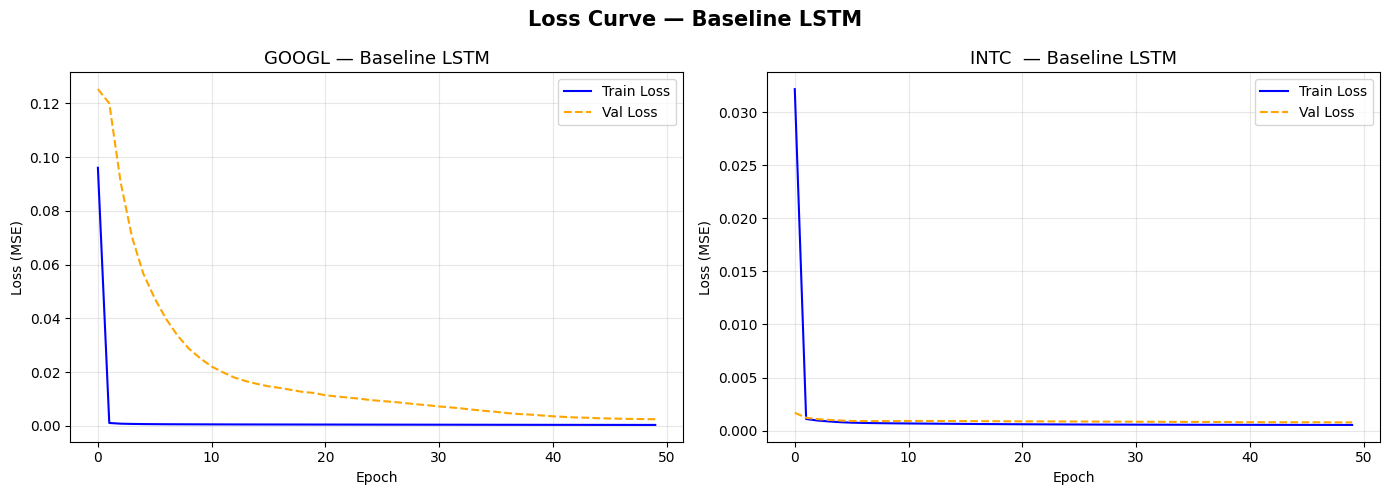

In [39]:
def plot_loss_curve(history, title, ax):
    ax.plot(history.history['loss'],     label='Train Loss', color='blue')
    ax.plot(history.history['val_loss'], label='Val Loss',   color='orange', linestyle='--')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE)')
    ax.legend()
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Loss Curve — Baseline LSTM', fontsize=15, fontweight='bold')

plot_loss_curve(history_baseline_googl, 'GOOGL — Baseline LSTM', axes[0])
plot_loss_curve(history_baseline_intc,  'INTC  — Baseline LSTM', axes[1])

plt.tight_layout()
plt.savefig('03_loss_curve_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

Kedua model menunjukkan proses pembelajaran yang stabil dengan penurunan **train loss** dan **validation loss** yang cepat pada awal pelatihan. Namun, pada saham **GOOGL** terlihat adanya selisih yang cukup besar antara train loss dan validation loss, yang mengindikasikan kecenderungan **overfitting**. Sebaliknya, pada **INTC** kedua kurva berada lebih dekat sehingga kemampuan generalisasinya lebih baik.

Hasil ini menunjukkan bahwa arsitektur baseline telah mampu mempelajari pola data, tetapi masih terdapat ruang untuk peningkatan performa, khususnya pada GOOGL. Oleh karena itu, pada tahap berikutnya akan dilakukan modifikasi arsitektur model untuk meningkatkan kemampuan generalisasi dan memperoleh performa prediksi yang lebih optimal.

## Modifikasi Arsitektur

### Improved Architecture

In [40]:
def build_improved_lstm(window_size=5):
    model = Sequential([
        Input(shape=(window_size, 1)),
        
        LSTM(units=50, activation='relu'),
        
        Dropout(0.1, name='Dropout'),
        
        # Output layer
        Dense(units=1, name='Output')
    ], name='Improved_LSTM')
    
    model.compile(
        optimizer=Adam(learning_rate=0.005),
        loss='mse',
        metrics=['mae']
    )
    return model

# Tampilkan arsitektur
improved_model = build_improved_lstm(WINDOW_SIZE)
improved_model.summary()

Model: "Improved_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_9 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Beberapa perubahan dilakukan pada model baseline untuk meningkatkan kemampuan model dalam menangkap pola data saham dan mengurangi risiko overfitting:

- **Menambahkan Dropout (0.1)** setelah layer LSTM untuk mengurangi overfitting dengan mencegah model terlalu bergantung pada neuron tertentu.
- **Menaikkan learning rate** dari **0.001 → 0.005** agar proses optimasi dapat bergerak lebih cepat menuju titik konvergensi.
- **Menambahkan ReduceLROnPlateau** untuk menurunkan learning rate secara otomatis ketika performa validasi (val_loss) tidak lagi meningkat, sehingga proses training menjadi lebih stabil pada tahap akhir.
- **Memperpanjang patience pada EarlyStopping** dari **15 → 20 epoch** agar model memiliki kesempatan training yang lebih panjang sebelum dihentikan, mengingat learning rate yang lebih besar dan adanya ReduceLROnPlateau.
- **Menurunkan batch size** dari **32 → 16** sehingga update bobot dilakukan lebih sering per epoch.

Jumlah unit LSTM (50) dan fungsi aktivasi (ReLU) pada layer LSTM tetap dipertahankan sama seperti model baseline, sehingga perbedaan performa antara kedua model murni berasal dari penambahan Dropout dan penyesuaian strategi training (learning rate, ReduceLROnPlateau, patience, dan batch size).

Modifikasi ini bertujuan untuk mengurangi overfitting dan membuat proses training lebih adaptif dibandingkan model baseline.

### Training Improved Model (GOOGL)

In [ ]:
callbacks_improved = [
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
]

print('Training Improved LSTM — GOOGL')
print('='*50)

improved_googl = build_improved_lstm(WINDOW_SIZE)

history_improved_googl = improved_googl.fit(
    X_train_g, y_train_g,
    epochs=50,
    batch_size=16,
    validation_data=(X_val_g, y_val_g),
    callbacks=callbacks_improved,
    verbose=1
)

Training Improved LSTM — GOOGL
Epoch 1/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0218 - mae: 0.0758 - val_loss: 0.0197 - val_mae: 0.1084 - learning_rate: 0.0050
Epoch 2/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0046 - mae: 0.0462 - val_loss: 0.0793 - val_mae: 0.2581 - learning_rate: 0.0050
Epoch 3/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0043 - mae: 0.0442 - val_loss: 0.0795 - val_mae: 0.2597 - learning_rate: 0.0050
Epoch 4/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0045 - mae: 0.0448 - val_loss: 0.0071 - val_mae: 0.0687 - learning_rate: 0.0050
Epoch 5/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0043 - mae: 0.0449 - val_loss: 0.0659 - val_mae: 0.2503 - learning_rate: 0.0050
Epoch 6/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0051 - mae: 0.0488 - val_loss: 0.0158 - val_mae: 0.1073 - learning_rate: 0.0050
Epoch 7/50
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0038 - mae: 0.0427 - val_loss: 0.0131 - val_mae: 0.0948

### Training Improved Model (INTC)

In [42]:
print('Training Improved LSTM — INTC')
print('='*50)

improved_intc = build_improved_lstm(WINDOW_SIZE)

history_improved_intc = improved_intc.fit(
    X_train_i, y_train_i,
    epochs=50,
    batch_size=16,
    validation_data=(X_val_i, y_val_i),
    callbacks=callbacks_improved,
    verbose=1
)

Training Improved LSTM — INTC
Epoch 1/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0088 - mae: 0.0573 - val_loss: 0.0013 - val_mae: 0.0250 - learning_rate: 0.0050
Epoch 2/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0043 - mae: 0.0458 - val_loss: 0.0023 - val_mae: 0.0404 - learning_rate: 0.0050
Epoch 3/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0042 - mae: 0.0435 - val_loss: 0.0092 - val_mae: 0.0829 - learning_rate: 0.0050
Epoch 4/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0040 - mae: 0.0435 - val_loss: 0.0020 - val_mae: 0.0373 - learning_rate: 0.0050
Epoch 5/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0037 - mae: 0.0413 - val_loss: 0.0028 - val_mae: 0.0464 - learning_rate: 0.0050
Epoch 6/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0035 - mae: 0.0409 - val_loss: 0.0061 - val_mae: 0.0686 - learning_rate: 0.0050
Epoch 7/50
554/554 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0038 - mae: 0.0411 - val_loss: 0.0014 - val_mae: 0.0290 

## Evaluasi Model

### Evaluasi RMSE, MAE, MAPE

In [ ]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_model(model, X_test, y_test_scaled, scaler, model_name, ticker):
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred_actual = scaler.inverse_transform(y_pred_scaled).flatten()
    y_true_actual = scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten()
    
    rmse_val = np.sqrt(mean_squared_error(y_true_actual, y_pred_actual))
    mae_val  = mean_absolute_error(y_true_actual, y_pred_actual)
    mape_val = mape(y_true_actual, y_pred_actual)
    
    print(f'  [{ticker}] {model_name}')
    print(f'    RMSE : {rmse_val:.4f}')
    print(f'    MAE  : {mae_val:.4f}')
    print(f'    MAPE : {mape_val:.4f}%')
    
    return y_pred_actual, y_true_actual, rmse_val, mae_val, mape_val

print('='*60)
print('EVALUASI BASELINE LSTM')
print('='*60)
pred_base_g, true_base_g, rmse_bg, mae_bg, mape_bg = evaluate_model(
    baseline_googl, X_test_g, y_test_g, scaler_googl, 'Baseline LSTM', 'GOOGL')
print()
pred_base_i, true_base_i, rmse_bi, mae_bi, mape_bi = evaluate_model(
    baseline_intc,  X_test_i, y_test_i, scaler_intc,  'Baseline LSTM', 'INTC')

print()
print('='*60)
print('EVALUASI IMPROVED LSTM')
print('='*60)
pred_impr_g, true_impr_g, rmse_ig, mae_ig, mape_ig = evaluate_model(
    improved_googl, X_test_g, y_test_g, scaler_googl, 'Improved LSTM', 'GOOGL')
print()
pred_impr_i, true_impr_i, rmse_ii, mae_ii, mape_ii = evaluate_model(
    improved_intc,  X_test_i, y_test_i, scaler_intc,  'Improved LSTM', 'INTC')

EVALUASI BASELINE LSTM
  [GOOGL] Baseline LSTM
    RMSE : 34.6447
    MAE  : 25.0889
    MAPE : 1.9857%

  [INTC] Baseline LSTM
    RMSE : 1.5634
    MAE  : 0.9317
    MAPE : 1.7696%

EVALUASI IMPROVED LSTM
  [GOOGL] Improved LSTM
    RMSE : 28.4726
    MAE  : 18.2837
    MAPE : 1.4842%

  [INTC] Improved LSTM
    RMSE : 1.6041
    MAE  : 0.9485
    MAPE : 1.8020%


### Visualisasi Prediksi vs Aktual (Test Set)

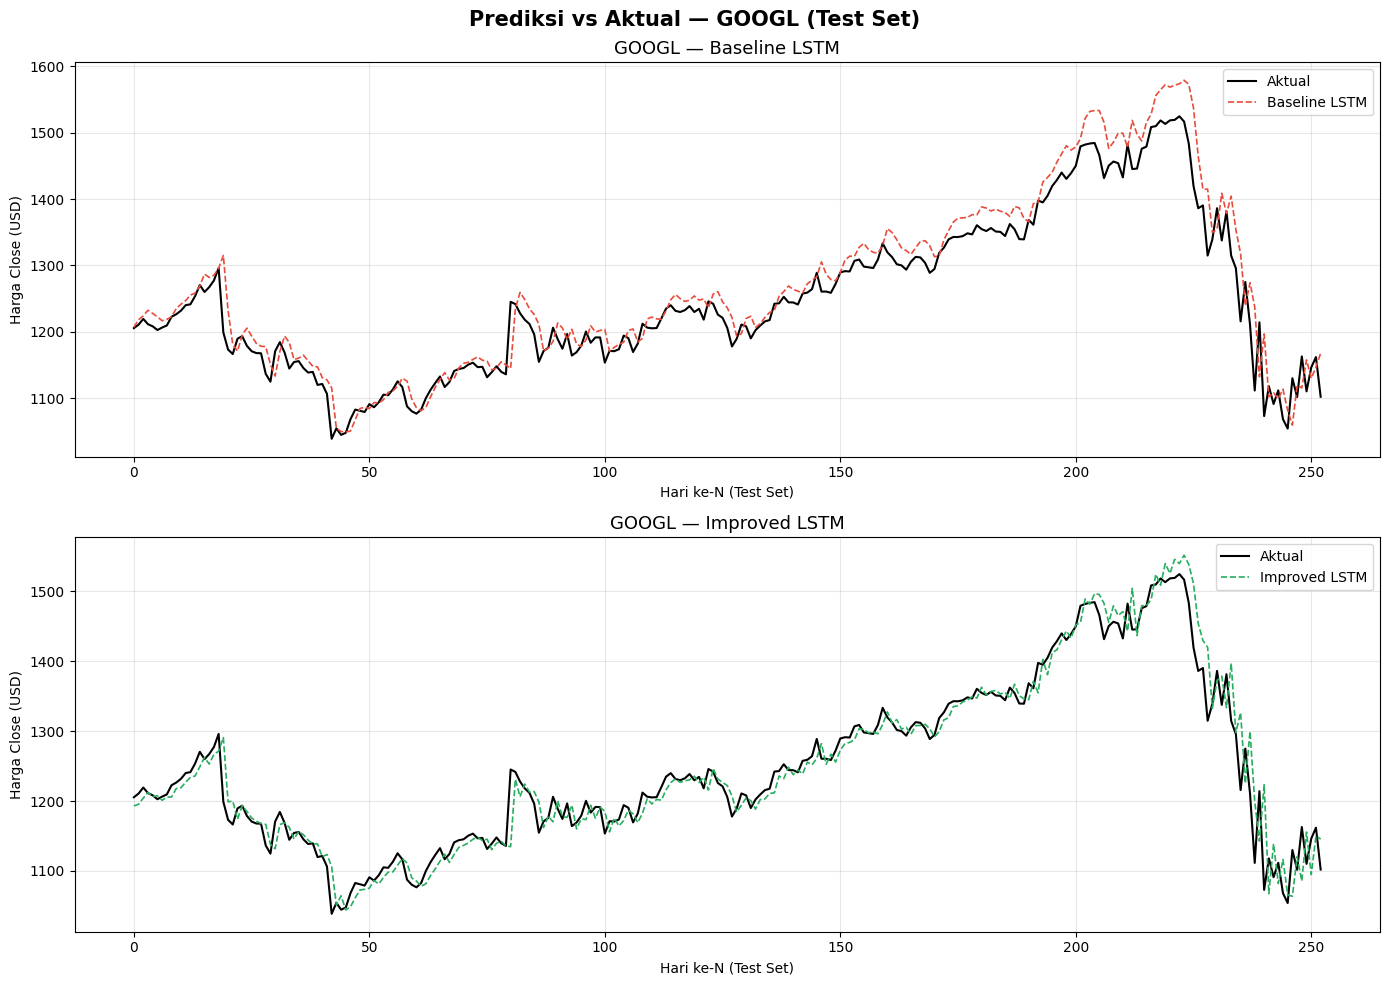

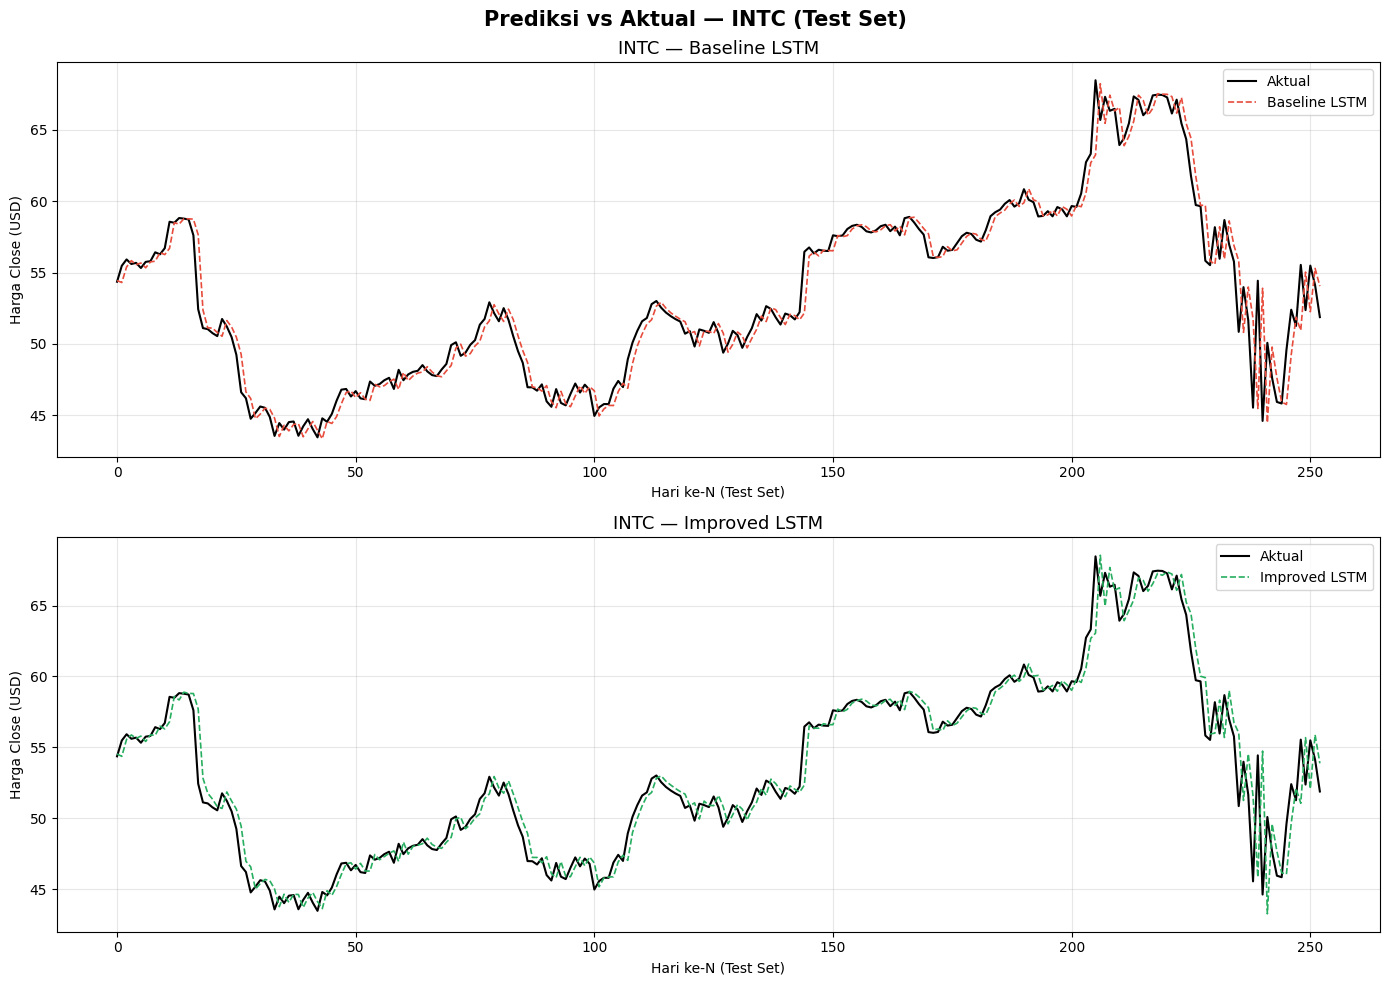

In [46]:
def plot_predictions(true_vals, pred_base, pred_impr, ticker, test_dates=None):
    n = len(true_vals)
    x_axis = range(n)
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.suptitle(f'Prediksi vs Aktual — {ticker} (Test Set)', fontsize=15, fontweight='bold')
    
    # Plot Baseline
    axes[0].plot(x_axis, true_vals,  label='Aktual',        color='black',  linewidth=1.5)
    axes[0].plot(x_axis, pred_base,  label='Baseline LSTM', color='#e74c3c', linewidth=1.2, linestyle='--')
    axes[0].set_title(f'{ticker} — Baseline LSTM', fontsize=13)
    axes[0].set_ylabel('Harga Close (USD)')
    axes[0].set_xlabel('Hari ke-N (Test Set)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot Improved
    axes[1].plot(x_axis, true_vals,  label='Aktual',        color='black',  linewidth=1.5)
    axes[1].plot(x_axis, pred_impr,  label='Improved LSTM', color='#27ae60', linewidth=1.2, linestyle='--')
    axes[1].set_title(f'{ticker} — Improved LSTM', fontsize=13)
    axes[1].set_ylabel('Harga Close (USD)')
    axes[1].set_xlabel('Hari ke-N (Test Set)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'05_prediksi_{ticker}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_predictions(true_base_g, pred_base_g, pred_impr_g, 'GOOGL')
plot_predictions(true_base_i, pred_base_i, pred_impr_i, 'INTC')

### Tabel Perbandingan Metrik

In [45]:
results_df = pd.DataFrame({
    'Saham'  : ['GOOGL', 'GOOGL', 'INTC', 'INTC'],
    'Model'  : ['Baseline LSTM', 'Improved LSTM', 'Baseline LSTM', 'Improved LSTM'],
    'RMSE'   : [rmse_bg, rmse_ig, rmse_bi, rmse_ii],
    'MAE'    : [mae_bg,  mae_ig,  mae_bi,  mae_ii],
    'MAPE(%)': [mape_bg, mape_ig, mape_bi, mape_ii]
})

print('='*60)
print('TABEL PERBANDINGAN METRIK EVALUASI')
print('='*60)
print(results_df.to_string(index=False, float_format='%.4f'))

TABEL PERBANDINGAN METRIK EVALUASI
Saham         Model    RMSE     MAE  MAPE(%)
GOOGL Baseline LSTM 34.6447 25.0889   1.9857
GOOGL Improved LSTM 28.4726 18.2837   1.4842
 INTC Baseline LSTM  1.5634  0.9317   1.7696
 INTC Improved LSTM  1.6041  0.9485   1.8020


Tabel di atas menunjukkan hasil yang berbeda arah antara kedua saham. Pada **GOOGL**, model improved berhasil menurunkan seluruh metrik secara signifikan (RMSE turun dari 34.64 menjadi 28.47, MAE dari 25.09 menjadi 18.28, dan MAPE dari 1.99% menjadi 1.48%). Sebaliknya, pada **INTC**, model improved justru sedikit lebih buruk dibandingkan baseline pada semua metrik (RMSE naik dari 1.5634 menjadi 1.6041, MAE dari 0.9317 menjadi 0.9485, MAPE dari 1.77% menjadi 1.80%), meskipun selisihnya relatif kecil.

Perbedaan arah hasil ini dapat dijelaskan oleh karakteristik data masing-masing saham:
- **Skala dan volatilitas harga.** Harga GOOGL lebih tinggi dan lebih fluktuatif dibanding INTC, sehingga Dropout dan ReduceLROnPlateau pada model improved lebih efektif menekan overfitting dan menurunkan error.
- **Data INTC yang lebih stabil.** Pola harga INTC lebih halus dan sederhana, sehingga model baseline saja sudah cukup optimal. Tambahan Dropout dan learning rate yang lebih besar pada model improved justru sedikit mengganggu proses belajar.
- **Trade-off regularisasi.** Dropout dan learning rate tinggi membantu pada data kompleks (GOOGL), tetapi pada data yang sudah sederhana (INTC) regularisasi ini hanya menambah noise, bukan manfaat.

Secara umum, hasil ini menunjukkan bahwa efektivitas modifikasi model bergantung pada karakteristik data. Modifikasi yang berhasil meningkatkan performa pada data GOOGL belum tentu memberikan peningkatan yang sama pada data INTC yang memiliki pola lebih stabil.